# Atividade Prática 1 (Arquitetura de Grandes Volumes de Dados)

**Membros:**

*   Giulia Monteiro Garrido (RA: 24010281)
*   Thomaz Dacorso (RA: 24012310)
*   Victor França (RA: 24010801)
*   Vitor Furuta (RA: 24008775)




### Importações inicias

In [ ]:
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aliiihussain/amazon-sales-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.
Path to dataset files: /kaggle/input/amazon-sales-dataset


In [ ]:
name_files = os.listdir(path)
new_path = path+"/"+name_files[0]
csv_file = open(new_path)

In [ ]:
df = pd.read_csv(csv_file)

In [ ]:
df.head(15)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
5,6,2023-12-02,1777,Sports,385.17,30,3,Asia,Wallet,3.8,489,269.62,808.86
6,7,2022-01-21,4068,Books,15.78,0,5,Asia,UPI,1.6,415,15.78,78.90
7,8,2023-09-07,3537,Fashion,111.59,30,4,Middle East,UPI,3.4,143,78.11,312.44
8,9,2022-05-02,3262,Books,373.62,0,4,Asia,Wallet,2.8,497,373.62,1494.48
9,10,2023-04-12,4174,Sports,134.81,15,2,Middle East,Cash on Delivery,2.0,25,114.59,229.18


# Análises Iniciais do Dataset

Conseguimos observar que o dataset possui 50.000 eventos registrados, sem nenhum dado faltante.

In [ ]:
df.info()
print("\n")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB




,0
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


Aqui podemos ver que a distribuição do numero de produtos comprados em cada categoria e bem uniforme


In [ ]:
print("CATEGORIAS: ")
print(df['product_category'].unique())

CATEGORIAS: 
['Books' 'Fashion' 'Sports' 'Beauty' 'Electronics' 'Home & Kitchen']


In [ ]:
category_frequency = df['product_category'].value_counts()
print(category_frequency)

product_category
Beauty            8465
Fashion           8365
Books             8327
Electronics       8320
Sports            8265
Home & Kitchen    8258
Name: count, dtype: int64


quantidade por regiao

In [ ]:
print("REGIOES: ")
print(df['customer_region'].unique())

REGIOES: 
['North America' 'Asia' 'Europe' 'Middle East']


In [ ]:
category_frequency = df['customer_region'].value_counts()
print(category_frequency)

customer_region
Asia             12526
North America    12517
Middle East      12505
Europe           12452
Name: count, dtype: int64


### Estatísticas Descritivas Unificadas

A seguir, uma tabela consolidada com as estatísticas descritivas (média, desvio padrão, mínimo, máximo, quartis) para as colunas 'price', 'discount_percent', 'quantity_sold', 'rating' e 'total_revenue'.

In [ ]:
description_df = pd.DataFrame()
columns_to_describe = ['price', 'discount_percent', 'quantity_sold', 'rating', 'total_revenue']

for col in columns_to_describe:
    desc = df[col].describe().rename(col)
    if description_df.empty:
        description_df = pd.DataFrame(desc)
    else:
        description_df = pd.concat([description_df, desc], axis=1)

display(description_df)

,price,discount_percent,quantity_sold,rating,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,252.507260,13.340700,2.999400,2.996316,657.331475
std,143.025544,9.850694,1.415401,1.154295,526.223968
min,5.010000,0.000000,1.000000,1.000000,3.840000
25%,127.840000,5.000000,2.000000,2.000000,240.320000
50%,252.970000,10.000000,3.000000,3.000000,505.410000
75%,376.335000,20.000000,4.000000,4.000000,968.970000
max,499.990000,30.000000,5.000000,5.000000,2499.550000


Vendo a distribuição das categorias pelas regioes também podemos ver que é uniforme

In [ ]:
regions=df['customer_region'].unique()
print(regions)

['North America' 'Asia' 'Europe' 'Middle East']


In [ ]:
regional_db=df[df['customer_region']=="North America"]

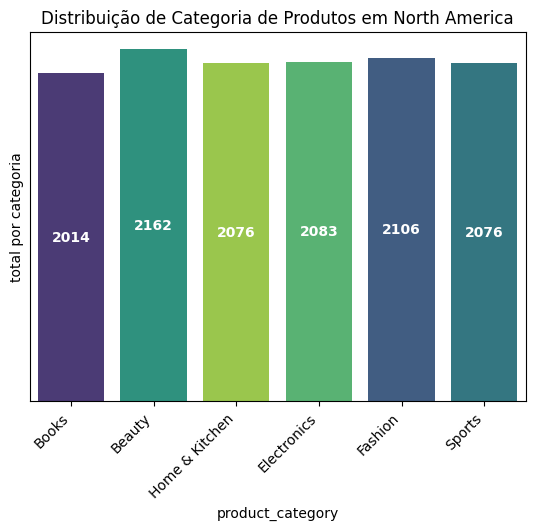

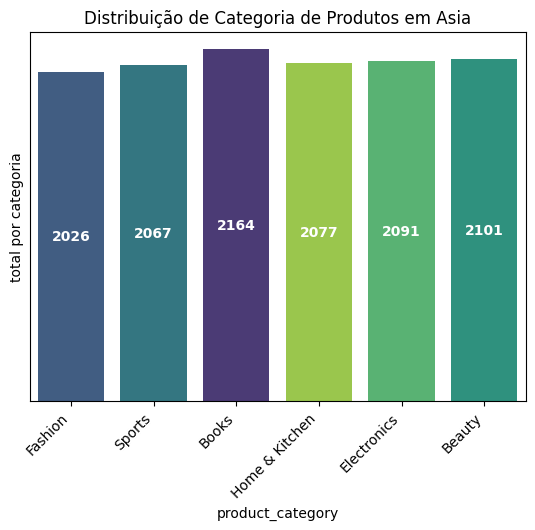

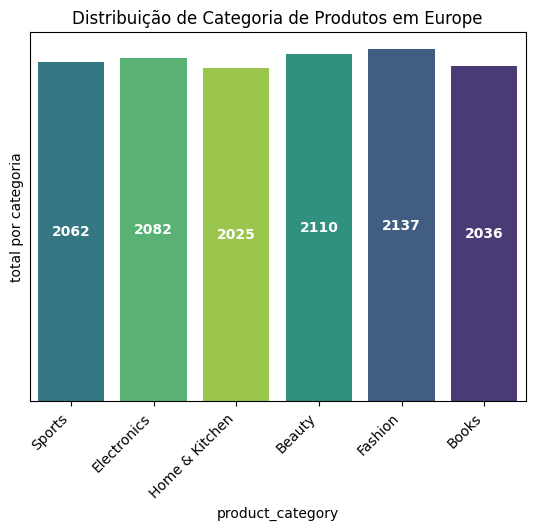

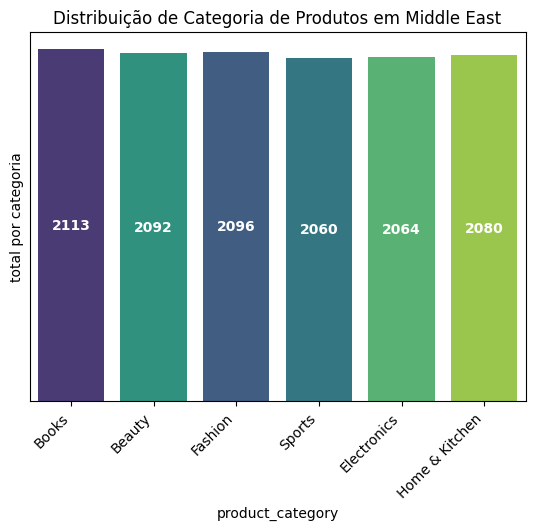

In [ ]:
for i in regions:
    regional_db = df[df['customer_region'] == i]
    ax = sns.countplot(data=regional_db, x="product_category", palette='viridis',
                       hue="product_category", hue_order=df['product_category'].unique())
    plt.title(f"Distribuição de Categoria de Produtos em {i}")
    plt.xticks(rotation=45, ha='right')

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='center', color='white', fontweight='bold')

        plt.yticks([])                # Remove os números/ticks
        ax.set_ylabel('total por categoria')

    plt.show()

Preço por categoria: o preço dos produtos de cada categoria de produtos também é parecido

In [ ]:

categories=df['product_category'].unique()
for i in categories:
  category_df=df[df['product_category']==i]
  print("categoria: ",i,"\n")
  print(category_df['price'].describe())
  print("#######\n\n")



categoria:  Books 

count    8327.000000
mean      252.682468
std       142.819741
min         5.010000
25%       129.905000
50%       254.830000
75%       374.515000
max       499.960000
Name: price, dtype: float64
#######


categoria:  Fashion 

count    8365.000000
mean      252.347879
std       143.593115
min         5.440000
25%       126.370000
50%       252.600000
75%       378.310000
max       499.990000
Name: price, dtype: float64
#######


categoria:  Sports 

count    8265.000000
mean      251.910161
std       143.218638
min         5.020000
25%       126.550000
50%       251.360000
75%       374.980000
max       499.910000
Name: price, dtype: float64
#######


categoria:  Beauty 

count    8465.000000
mean      252.405289
std       142.298185
min         5.300000
25%       128.120000
50%       252.560000
75%       375.390000
max       499.930000
Name: price, dtype: float64
#######


categoria:  Electronics 

count    8320.000000
mean      251.893404
std       142.716925
min

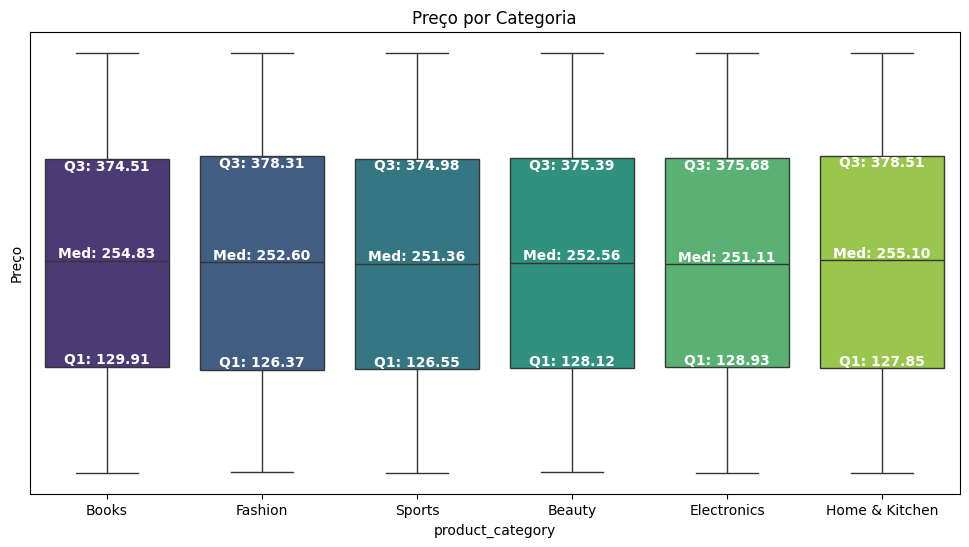

In [ ]:

plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df, x="product_category", y="price", palette='viridis',
                 hue="product_category", hue_order=df['product_category'].unique())
plt.title("Preço por Categoria")

for i, category in enumerate(df['product_category'].unique()):
    q1 = df[df['product_category'] == category]['price'].quantile(0.25)
    q3 = df[df['product_category'] == category]['price'].quantile(0.75)
    median = df[df['product_category'] == category]['price'].median()

    ax.text(i, median, f'Med: {median:.2f}', ha='center', va='bottom', color='white', fontweight='bold')
    ax.text(i, q1, f'Q1: {q1:.2f}', ha='center', va='bottom', color='white', fontweight='bold')
    ax.text(i, q3, f'Q3: {q3:.2f}', ha='center', va='top', color='white', fontweight='bold')

plt.yticks([])
ax.set_ylabel('Preço')
plt.show()

**Total de receitapor categoria**

In [ ]:
for i in categories:
  category_df=df[df['product_category']==i]
  sum=0
  for j in range(len(category_df)):
    sum+=category_df.iloc[j]['total_revenue']
  print("categoria: ",i,"\n")
  print("renda total somada: ",sum)
  print("#######\n\n")


categoria:  Books 

renda total somada:  5484863.029999998
#######


categoria:  Fashion 

renda total somada:  5480123.339999994
#######


categoria:  Sports 

renda total somada:  5407235.819999999
#######


categoria:  Beauty 

renda total somada:  5550624.970000026
#######


categoria:  Electronics 

renda total somada:  5470594.030000019
#######


categoria:  Home & Kitchen 

renda total somada:  5473132.549999997
#######




In [ ]:
# Calcular a soma total da receita por categoria
total_revenue_per_category = df.groupby('product_category')['total_revenue'].sum().reset_index()

# Exibir a tabela com as somas
display(total_revenue_per_category)

,product_category,total_revenue
0,Beauty,5550624.97
1,Books,5484863.03
2,Electronics,5470594.03
3,Fashion,5480123.34
4,Home & Kitchen,5473132.55
5,Sports,5407235.82


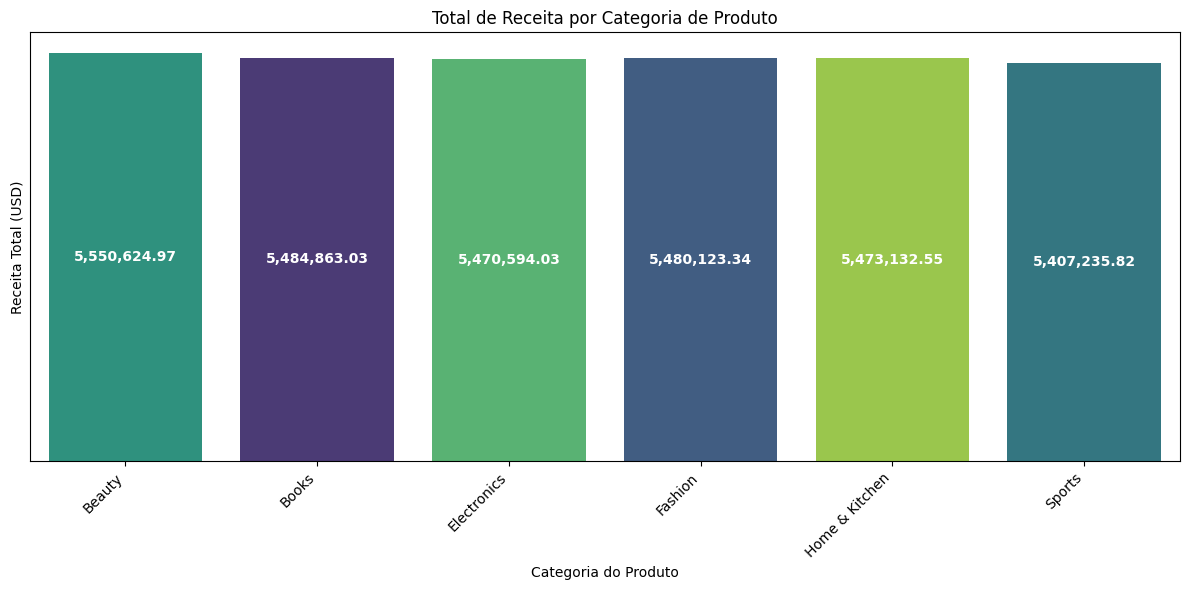

In [ ]:
# Criar o gráfico de barras para comparar o total de receita por categoria
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='product_category', y='total_revenue', data=total_revenue_per_category,
                 palette='viridis', hue="product_category", hue_order=df['product_category'].unique())
plt.title('Total de Receita por Categoria de Produto')
plt.xlabel('Categoria do Produto')
plt.ylabel('Receita Total (USD)')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x:,.2f}', label_type='center', color='white', fontweight='bold')

plt.yticks([])
ax.set_ylabel('Receita Total (USD)')

plt.tight_layout()
plt.show()

In [ ]:
# Calcular a soma total da receita por categoria
total_revenue_per_category = df.groupby('payment_method')['total_revenue'].sum().reset_index()

# Exibir a tabela com as somas
display(total_revenue_per_category)

,payment_method,total_revenue
0,Cash on Delivery,6546386.94
1,Credit Card,6540087.16
2,Debit Card,6522019.73
3,UPI,6579441.44
4,Wallet,6678638.47


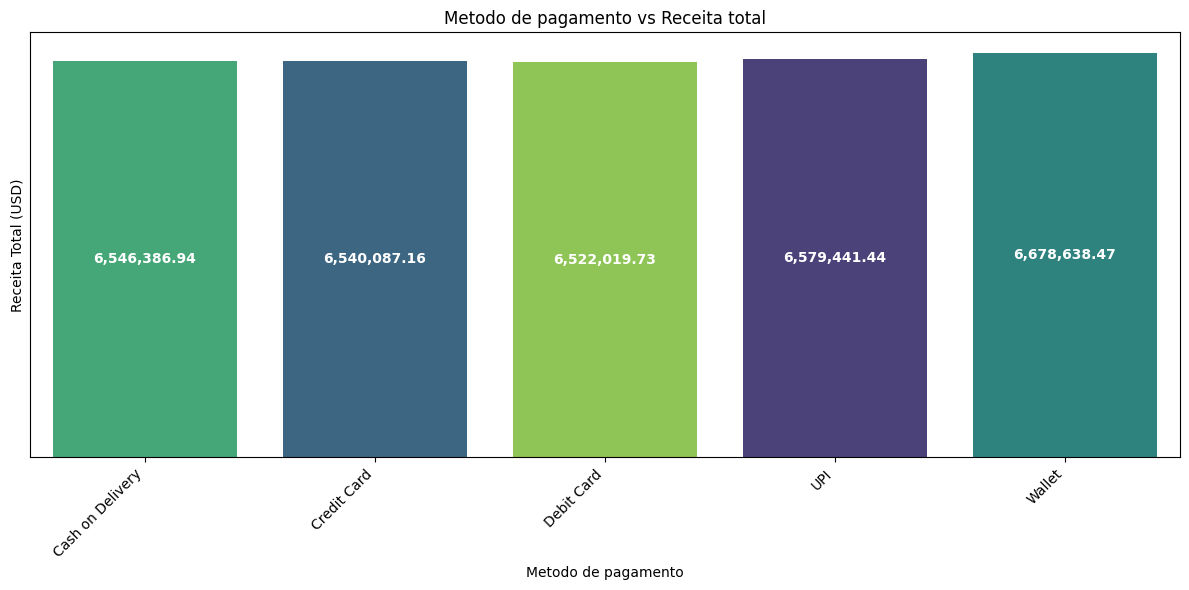

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='payment_method', y='total_revenue', data=total_revenue_per_category,
                 palette='viridis', hue="payment_method", hue_order=df['payment_method'].unique())
plt.title('Metodo de pagamento vs Receita total')
plt.xlabel('Metodo de pagamento')
plt.ylabel('Receita Total (USD)')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x:,.2f}', label_type='center', color='white', fontweight='bold')

plt.yticks([])
ax.set_ylabel('Receita Total (USD)')

plt.tight_layout()
plt.show()

,payment_method,total_revenue
0,Cash on Delivery,6546386.94
1,Credit Card,6540087.16
2,Debit Card,6522019.73
3,UPI,6579441.44
4,Wallet,6678638.47


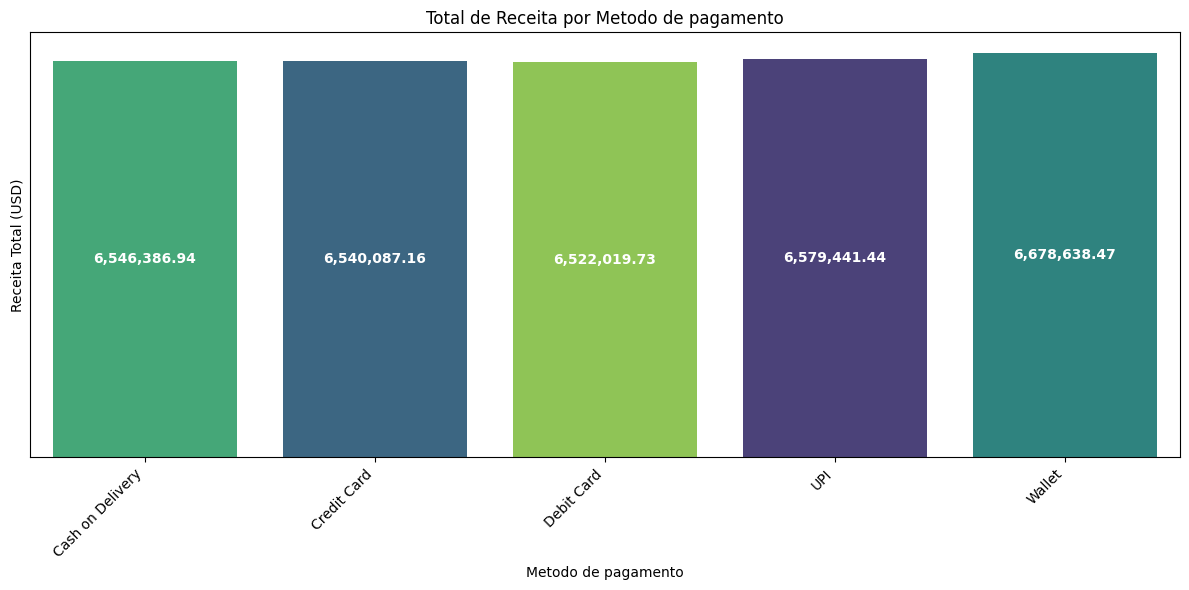

In [ ]:
# Calcular a soma total da receita por categoria
total_revenue_per_category = df.groupby('payment_method')['total_revenue'].sum().reset_index()

# Exibir a tabela com as somas
display(total_revenue_per_category)


plt.figure(figsize=(12, 6))
ax = sns.barplot(x='payment_method', y='total_revenue', data=total_revenue_per_category,
                 palette='viridis', hue="payment_method", hue_order=df['payment_method'].unique())
plt.title('Total de Receita por Metodo de pagamento')
plt.xlabel('Metodo de pagamento')
plt.ylabel('Receita Total (USD)')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x:,.2f}', label_type='center', color='white', fontweight='bold')

plt.yticks([])
ax.set_ylabel('Receita Total (USD)')

plt.tight_layout()
plt.show()

,payment_method,total_revenue
0,Cash on Delivery,1641735.00
1,Credit Card,1623669.82
2,Debit Card,1655833.38
3,UPI,1646440.37
4,Wallet,1709539.27


AttributeError: 'str' object has no attribute 'items'

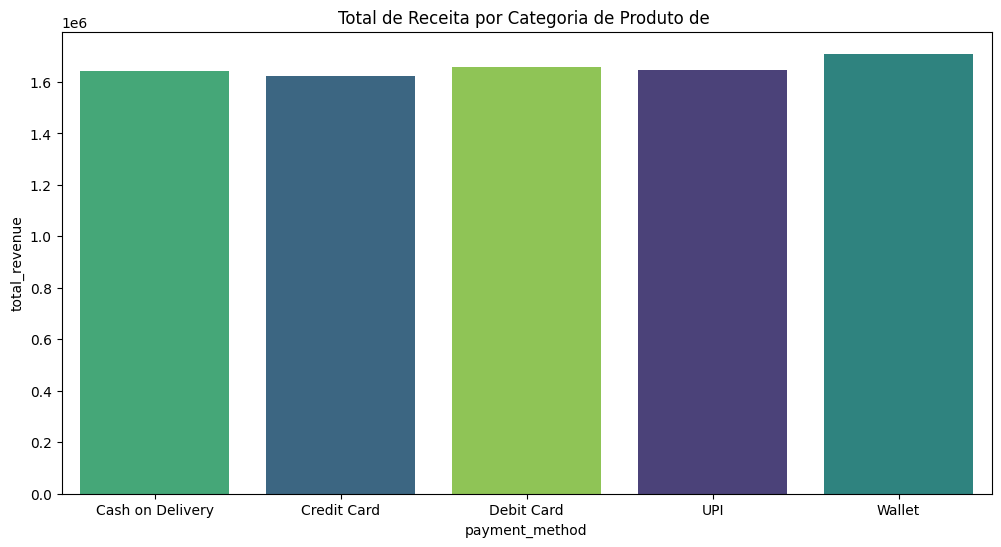

In [ ]:
for i in regions:
  regional_db = df[df['customer_region'] == i]

  # Calcular a soma total da receita por categoria
  total_revenue_per_category = regional_db.groupby('payment_method')['total_revenue'].sum().reset_index()

  # Exibir a tabela com as somas
  display(total_revenue_per_category)


  plt.figure(figsize=(12, 6))
  ax = sns.barplot(x='payment_method', y='total_revenue', data=total_revenue_per_category,
  palette='viridis', hue="payment_method", hue_order=df['payment_method'].unique())
  plt.title('Total de Receita por Categoria de Produto de ',str(i))
  plt.xlabel('Categoria do Produto')
  plt.ylabel('Receita Total (USD)')
  plt.xticks(rotation=45, ha='right')

  for container in ax.containers:
      ax.bar_label(container, fmt=lambda x: f'{x:,.2f}', label_type='center', color='white', fontweight='bold')

  plt.yticks([])
  ax.set_ylabel('Receita Total (USD)')

  plt.tight_layout()
  plt.show()

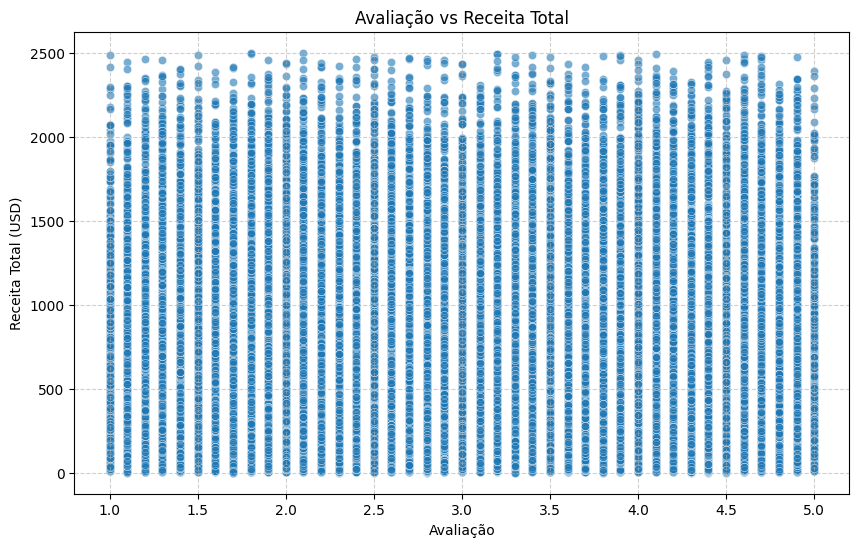

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='rating', y='total_revenue', alpha=0.6)
plt.title('Avaliação vs Receita Total')
plt.xlabel('Avaliação')
plt.ylabel('Receita Total (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

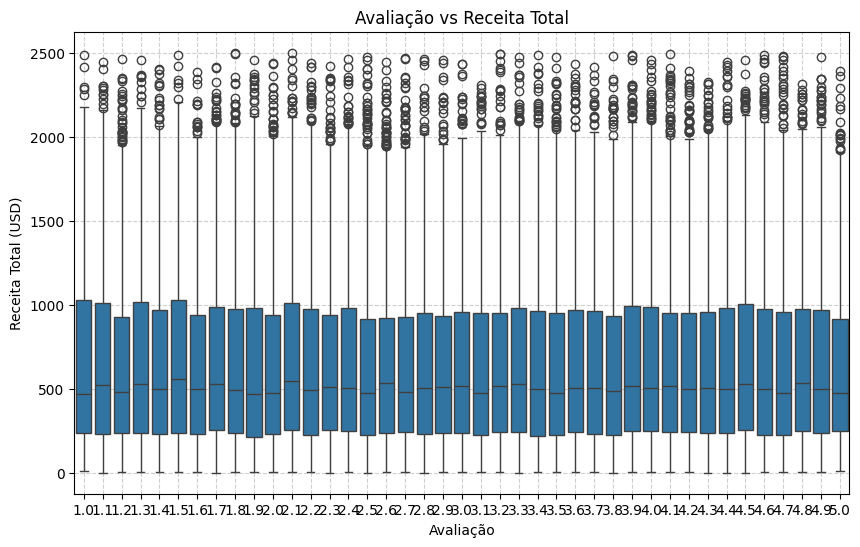

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='rating', y='total_revenue')
plt.title('Avaliação vs Receita Total')
plt.xlabel('Avaliação')
plt.ylabel('Receita Total (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

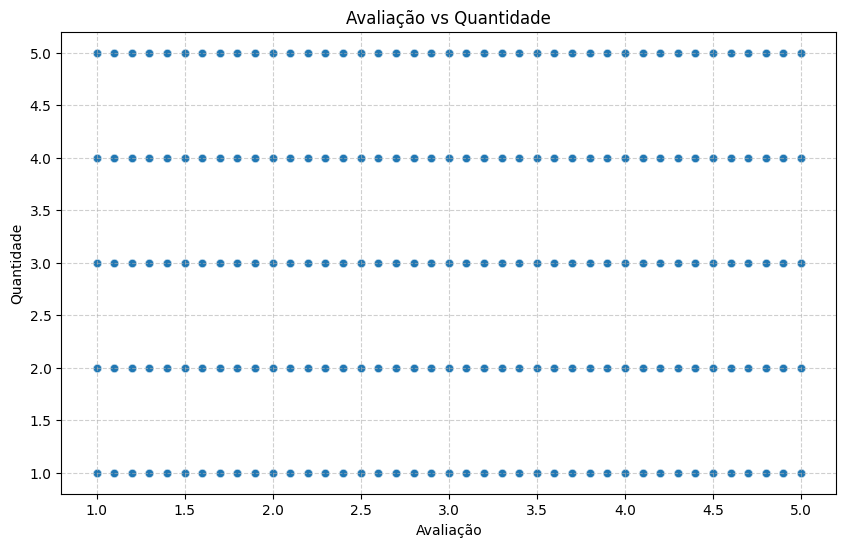

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='rating', y='quantity_sold', alpha=0.6)
plt.title('Avaliação vs Quantidade')
plt.xlabel('Avaliação')
plt.ylabel('Quantidade')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

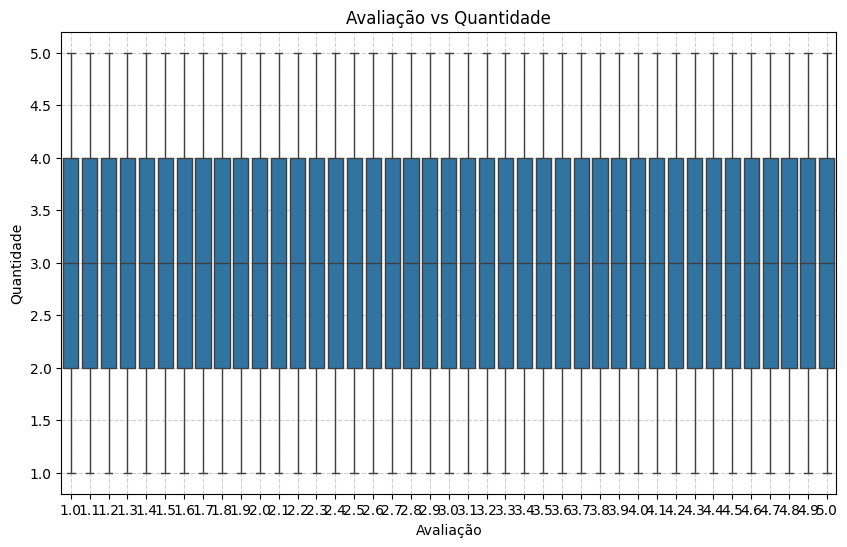

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='rating', y='quantity_sold')
plt.title('Avaliação vs Quantidade')
plt.xlabel('Avaliação')
plt.ylabel('Quantidade')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Visualização da Matriz de Correlação
Vamos calcular a matriz de correlação para as colunas numéricas do DataFrame e exibi-la como um mapa de calor. Valores próximos de `1` ou `-1` indicam uma correlação linear forte (positiva ou negativa, respectivamente), enquanto valores próximos de `0` indicam pouca ou nenhuma correlação linear.

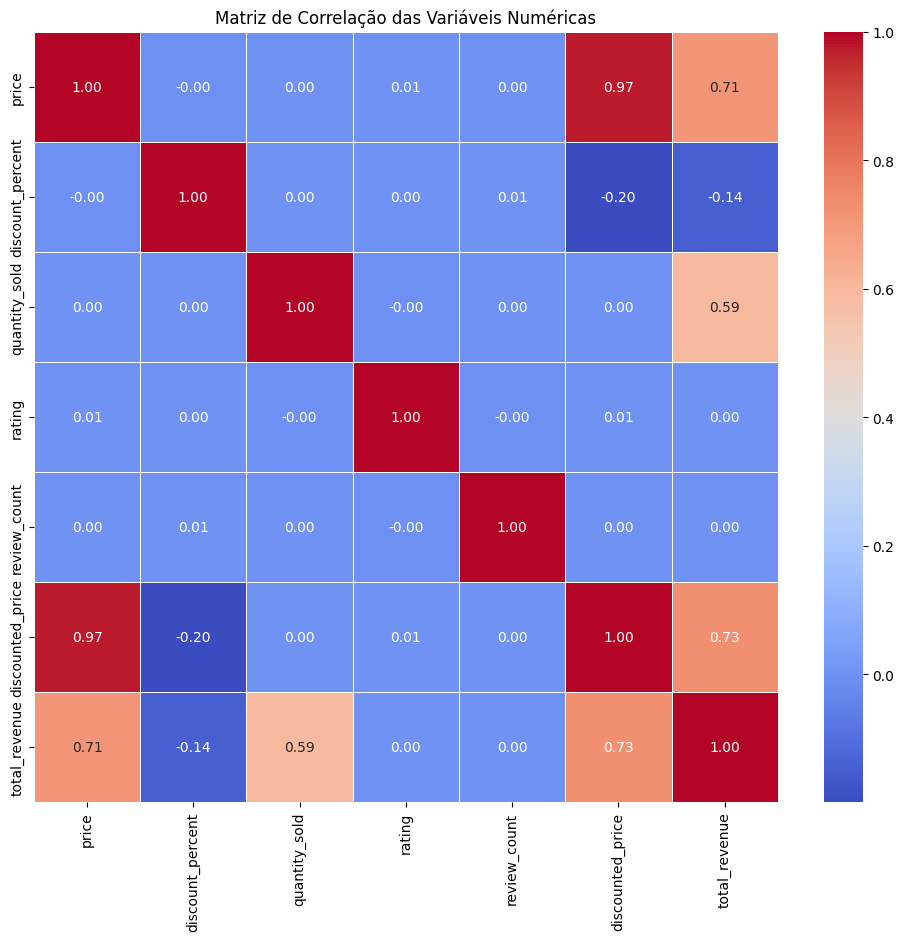

In [ ]:
# Selecionar apenas as colunas numéricas para o cálculo da correlação
# (excluindo 'order_id' e 'product_id' que são identificadores e não medidas quantitativas)
numerical_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['order_id', 'product_id'])

# Calcular a matriz de correlação
correlation_matrix = numerical_df.corr()

# Criar o mapa de calor da correlação
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

#### Visualizando Relações de Alta Correlação

Com base na matriz de correlação, as colunas com a maior correlação são `total_revenue`, `discounted_price` e `price`. Vou criar gráficos de dispersão para visualizar essas relações.

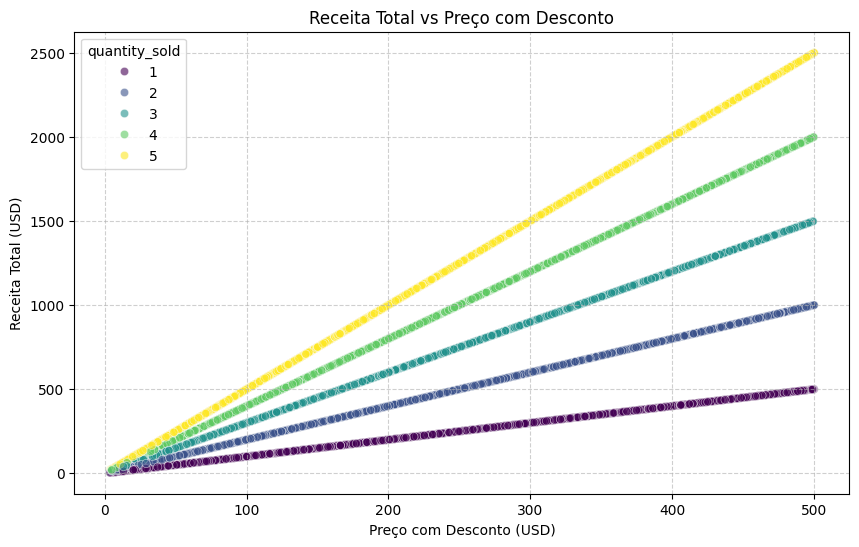

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='discounted_price', y='total_revenue', alpha=0.6, palette='viridis',hue="quantity_sold", hue_order=df['quantity_sold'].unique())
plt.title('Receita Total vs Preço com Desconto')
plt.xlabel('Preço com Desconto (USD)')
plt.ylabel('Receita Total (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

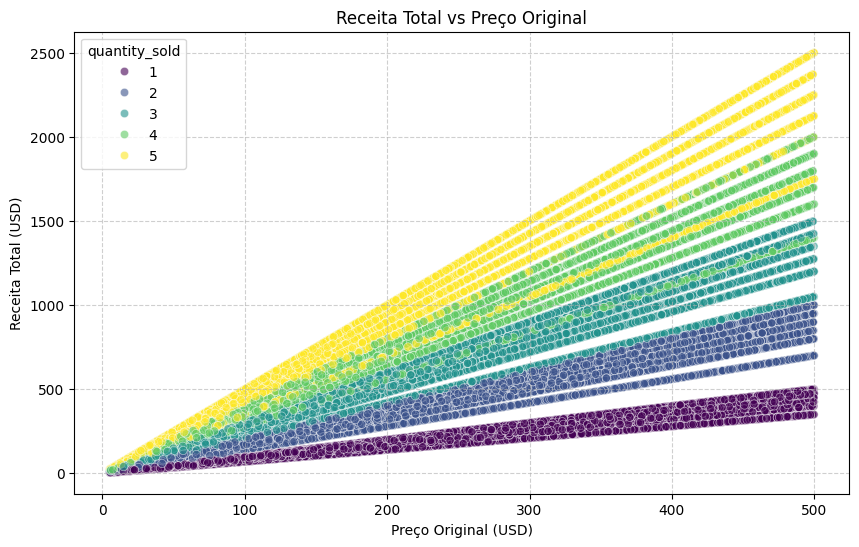

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='total_revenue', alpha=0.6, palette='viridis',hue="quantity_sold", hue_order=df['quantity_sold'].unique())
plt.title('Receita Total vs Preço Original')
plt.xlabel('Preço Original (USD)')
plt.ylabel('Receita Total (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

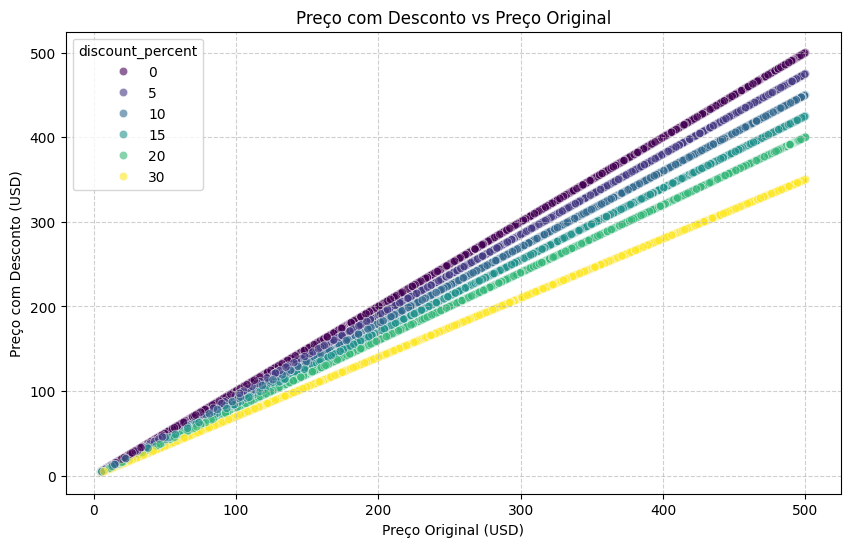

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='discounted_price', alpha=0.6, palette='viridis',hue="discount_percent", hue_order=df['discount_percent'].unique())
plt.title('Preço com Desconto vs Preço Original')
plt.xlabel('Preço Original (USD)')
plt.ylabel('Preço com Desconto (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

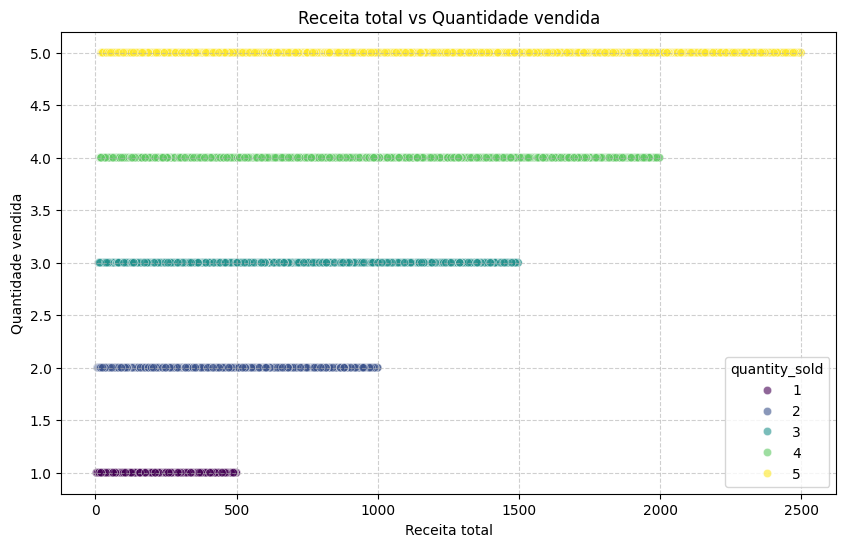

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_revenue', y='quantity_sold', alpha=0.6, palette='viridis',hue="quantity_sold", hue_order=df['quantity_sold'].unique())
plt.title('Receita total vs Quantidade vendida')
plt.xlabel('Receita total')
plt.ylabel('Quantidade vendida')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

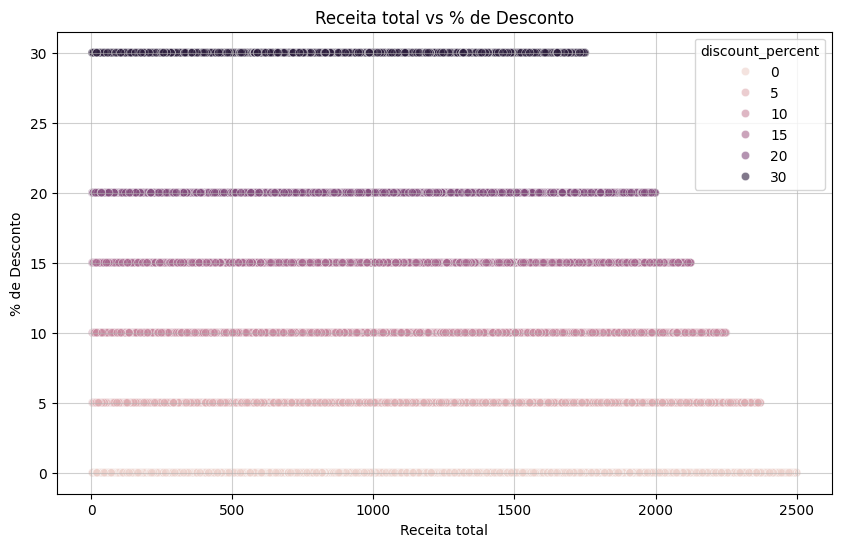

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_revenue', y='discount_percent', alpha=0.6,hue="discount_percent", hue_order=df['discount_percent'].unique())
plt.title('Receita total vs % de Desconto')
plt.xlabel('Receita total')
plt.ylabel('% de Desconto')
plt.grid(True, alpha=0.6)
plt.show()

In [ ]:
# Calcular a soma total da receita por percentual de desconto
total_revenue_per_discount = df.groupby('discount_percent')['total_revenue'].sum().reset_index()

# Exibir a tabela com as somas
display(total_revenue_per_discount)

,discount_percent,total_revenue
0,0,6154055.31
1,5,6182826.90
2,10,5732411.47
3,15,5322103.91
4,20,5128525.23
5,30,4346650.92


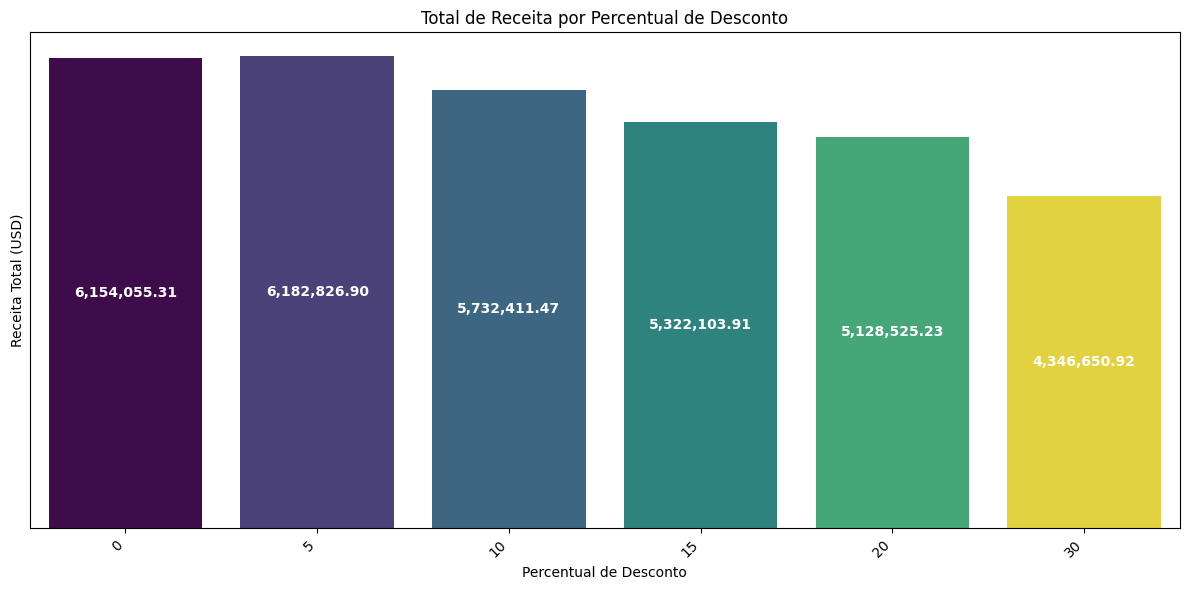

In [ ]:
# Criar o gráfico de barras para comparar o total de receita por percentual de desconto
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='discount_percent', y='total_revenue', data=total_revenue_per_discount,
                 palette='viridis', hue='discount_percent', legend=False)
plt.title('Total de Receita por Percentual de Desconto')
plt.xlabel('Percentual de Desconto')
plt.ylabel('Receita Total (USD)')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x:,.2f}', label_type='center', color='white', fontweight='bold')

plt.yticks([])
ax.set_ylabel('Receita Total (USD)')

plt.tight_layout()
plt.show()

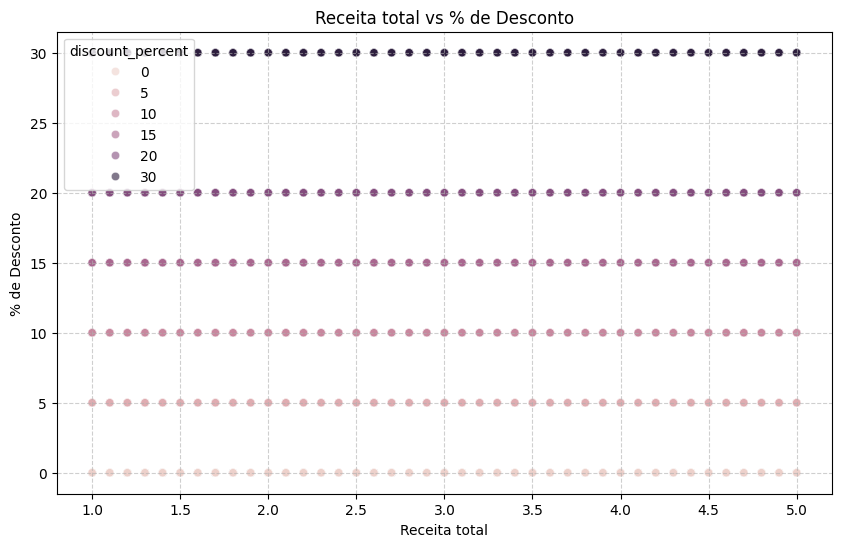

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='rating', y='discount_percent', alpha=0.6,hue="discount_percent", hue_order=df['discount_percent'].unique())
plt.title('Receita total vs % de Desconto')
plt.xlabel('Receita total')
plt.ylabel('% de Desconto')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Análise com timestamp

converter a coluna order_date de string para datatime

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
print('Coluna order_date convertida para datetime')

Coluna order_date convertida para datetime


In [ ]:
# Assegurar que 'order_date' está em formato datetime e criar 'year_month_str'
# df['order_date'] já foi convertido para datetime anteriormente

df['year_month'] = df['order_date'].dt.strftime('%Y-%m')

# Agrupar por mês/ano e região para contar os pedidos
freq_time_seaborn = df.groupby(['year_month', 'customer_region']).size().reset_index(name='order_count')

# Exibir as primeiras linhas dos dados agregados
display(freq_time_seaborn.head())

,year_month,customer_region,order_count
0,2022-01,Asia,555
1,2022-01,Europe,552
2,2022-01,Middle East,530
3,2022-01,North America,514
4,2022-02,Asia,447


receita total por mes

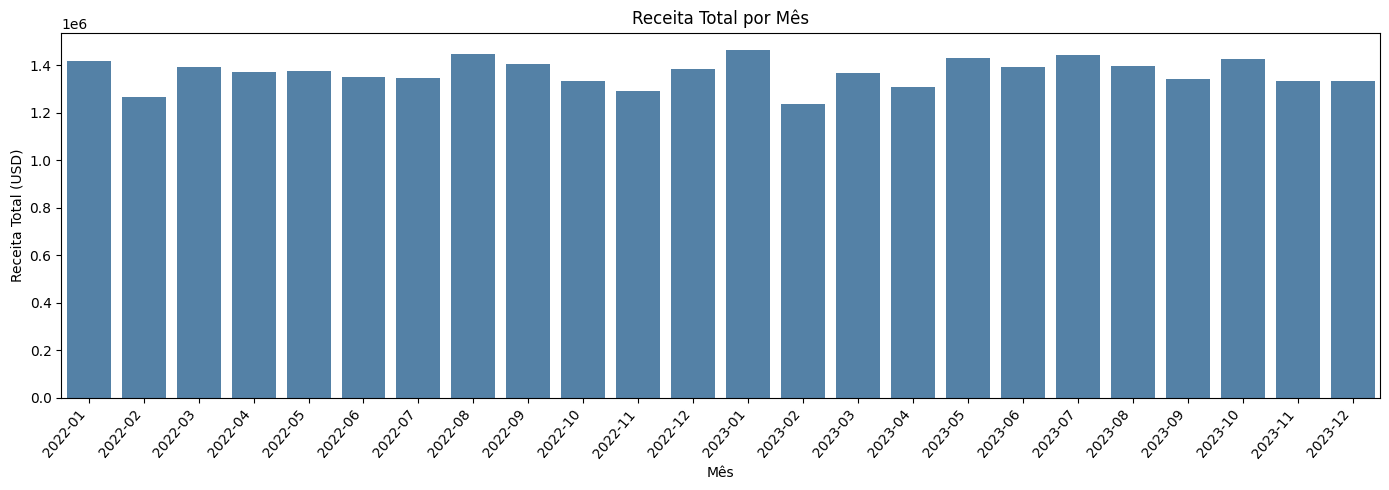

In [ ]:
# Receita total por mês
receita_mensal = df.groupby(df['order_date'].dt.to_period('M'))['total_revenue'].sum().reset_index()
receita_mensal['order_date'] = receita_mensal['order_date'].astype(str)

plt.figure(figsize=(14, 5))
sns.barplot(data=receita_mensal, x='order_date', y='total_revenue', color='steelblue')
plt.title('Receita Total por Mês')
plt.xlabel('Mês')
plt.ylabel('Receita Total (USD)')
plt.xticks(rotation=50, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
receita_mensal.head()

,order_date,total_revenue
0,2022-01,1419751.89
1,2022-02,1266714.29
2,2022-03,1392585.42
3,2022-04,1371955.83
4,2022-05,1374779.57


categoria mais vendida por mes

preço medio da categoria por mes

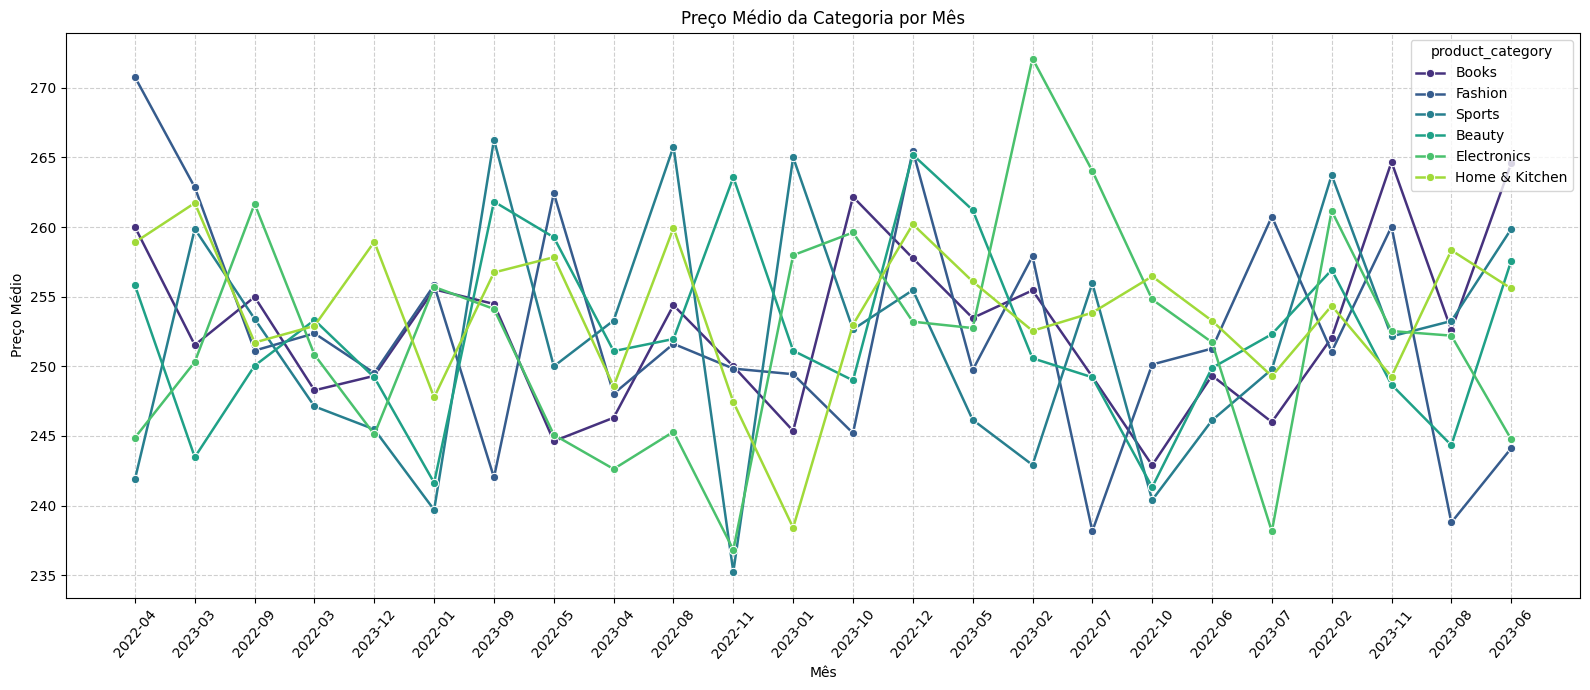

In [ ]:
plt.figure(figsize=(16, 7))
sns.lineplot(data=df, x='year_month', y='price', hue='product_category', marker="o", palette='viridis', errorbar=None, linewidth=1.8)
plt.title('Preço Médio da Categoria por Mês')
plt.xlabel('Mês')
plt.ylabel('Preço Médio')
plt.xticks(rotation=50)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Frequência de Pedidos por Região ao Longo do Tempo (Seaborn)

Para reproduzir o gráfico de frequência de pedidos por região usando Seaborn, precisamos primeiro preparar os dados agregando o número de pedidos (`order_id`) por mês/ano (`year_month_str`) e `customer_region`. Em seguida, utilizaremos `sns.lineplot`.

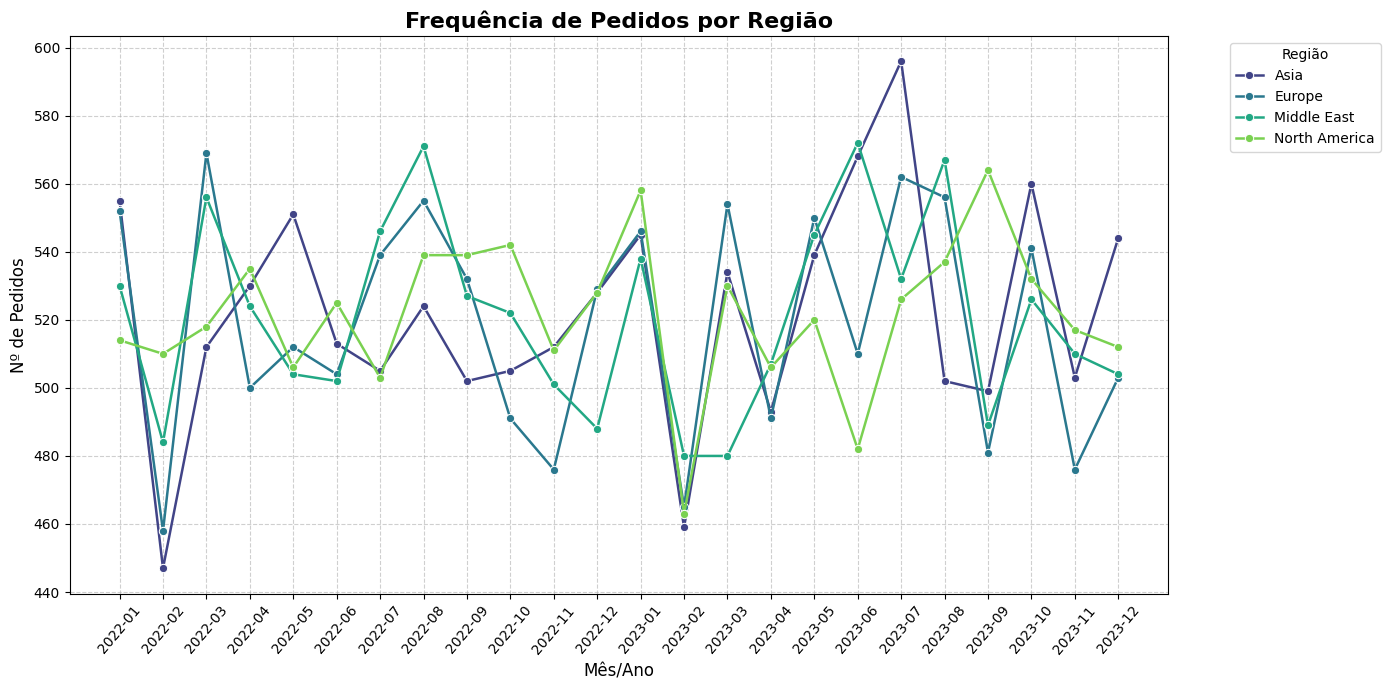

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=freq_time_seaborn, x='year_month', y='order_count', hue='customer_region', marker='o', palette='viridis', linewidth=1.8)

plt.title('Frequência de Pedidos por Região', fontsize=16, fontweight='bold')
plt.xlabel('Mês/Ano', fontsize=12)
plt.ylabel('Nº de Pedidos', fontsize=12)
plt.xticks(rotation=50)
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left') # Posiciona a legenda fora do gráfico
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

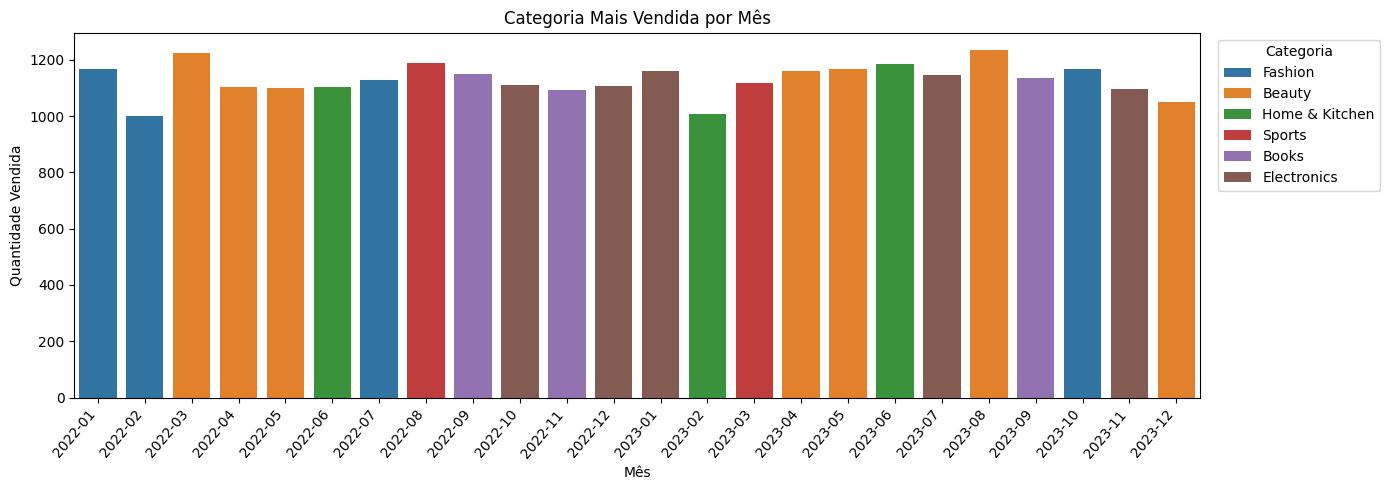

In [ ]:
color_map = {
    'Fashion':        '#1f77b4',
    'Beauty':         '#ff7f0e',
    'Home & Kitchen': '#2ca02c',
    'Sports':         '#d62728',
    'Books':          '#9467bd',
    'Electronics':    '#8c564b',
}

top_cat = df.groupby(['year_month', 'product_category'])['quantity_sold'].sum().reset_index()
top_cat = top_cat.loc[top_cat.groupby('year_month')['quantity_sold'].idxmax()]

plt.figure(figsize=(14, 5))
sns.barplot(data=top_cat, x='year_month', y='quantity_sold', hue='product_category',
            dodge=False, palette=color_map)
plt.title('Categoria Mais Vendida por Mês')
plt.xlabel('Mês')
plt.ylabel('Quantidade Vendida')
plt.xticks(rotation=50, ha='right')
plt.legend(title='Categoria', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

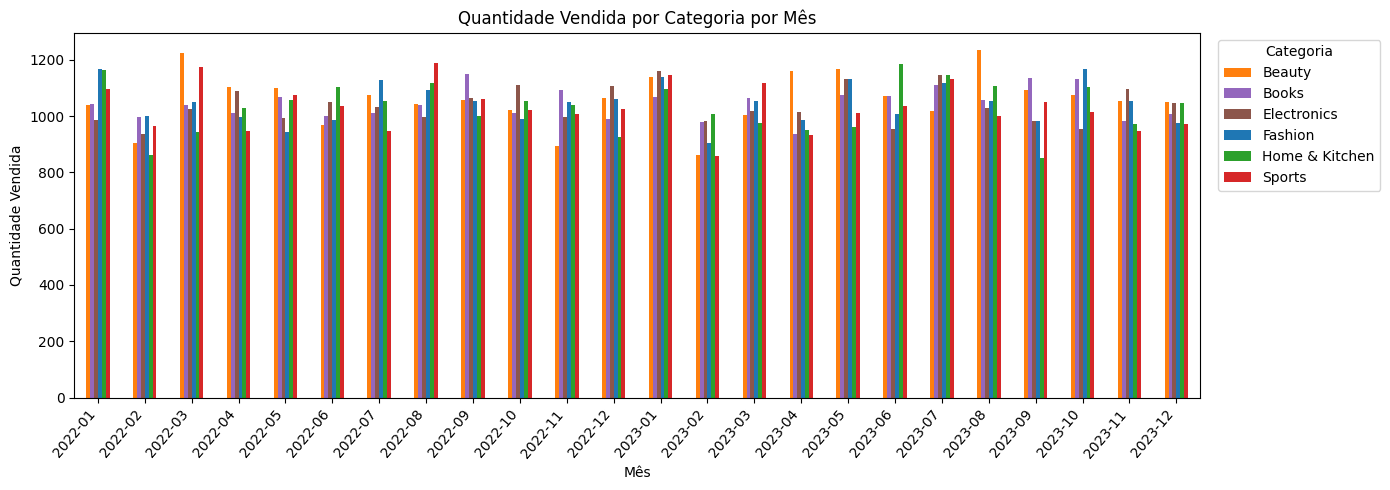

In [ ]:


cat_month = df.groupby(['year_month', 'product_category'])['quantity_sold'].sum().unstack().fillna(0)

cat_month.plot(kind='bar', stacked=False, figsize=(14, 5),
               color=[color_map[c] for c in cat_month.columns])
plt.title('Quantidade Vendida por Categoria por Mês')
plt.xlabel('Mês')
plt.ylabel('Quantidade Vendida')
plt.xticks(rotation=50, ha='right')
plt.legend(title='Categoria', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
avg_price = df.groupby(['year_month', 'product_category'])['price'].mean().reset_index()

fig = go.Figure()

for cat in sorted(df['product_category'].unique()):
    d = avg_price[avg_price['product_category'] == cat]
    fig.add_trace(go.Scatter(
        x=d['year_month'],
        y=d['price'],
        mode='lines+markers',
        name=cat,
        line=dict(width=1.5),
        marker=dict(size=5)
    ))

# Botões para destacar uma categoria por vez
buttons = [dict(
    label='Todas',
    method='update',
    args=[{'line': [dict(width=1.5)] * len(fig.data),
           'opacity': [1] * len(fig.data)}]
)]

for i, cat in enumerate(sorted(df['product_category'].unique())):
    visibility = [dict(width=1, color='lightgray')] * len(fig.data)
    opacity = [0.2] * len(fig.data)
    visibility[i] = dict(width=3)
    opacity[i] = 1
    buttons.append(dict(
        label=cat,
        method='update',
        args=[{'line': visibility, 'opacity': opacity}]
    ))

fig.update_layout(
    title='Preço Médio por Categoria ao Longo do Tempo',
    xaxis_title='Mês',
    yaxis_title='Preço Médio (USD)',
    xaxis=dict(tickangle=45),
    updatemenus=[dict(
        type='dropdown',
        x=1.15, y=1.1,
        buttons=buttons,
        showactive=True
    )],
    legend=dict(title='Categoria'),
    hovermode='x unified',
    width=1000,
    height=500
)

fig.show()

# Links Externos

Gráficos visualmente exemplificados: https://seaborn.pydata.org/examples/index.html

Docx: https://docs.google.com/document/d/1gG23tdTWLd0XOZhJuY4mVlOA1pxyU_cC_V-PQktoB78/edit?usp=sharing